In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("D:/DLM Research/merged_data.csv")

In [3]:
df

,placenta,MRN,exam_date,delivery_date,pnt_mrn,ancc_hx,still_birth,fund_height,chief_compl,maternal_status,...,hpi,integ_syst,past_med_surg_hstry,under_illness,dur_illness_type,neur_syst,lgs,fet_heart_beat,gus,Institution
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yekatit Hospital
1,Completed,NaN,NaN,2021-03-04 00:00:00,NaN,NaN,NaN,NaN,NaN,Stable,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yekatit Hospital
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yekatit Hospital
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yekatit Hospital
4,NaN,NaN,2021-04-17 00:00:00,NaN,NaN,no,NaN,test,test,NaN,...,test,NaN,test,"none,",NaN,NaN,NaN,NaN,NaN,Yekatit Hospital
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
646034,NaN,NaN,NaN,NaN,861121.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Zewuditu Hospital
646035,NaN,NaN,NaN,NaN,861122.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Zewuditu Hospital
646036,NaN,NaN,NaN,NaN,861123.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Zewuditu Hospital
646037,NaN,NaN,NaN,NaN,861124.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Zewuditu Hospital


In [4]:
# Drop columns where all values are null
df = df.dropna(axis=1, how='all')

In [5]:
threshold_row = 0.4 * df.shape[1]   # at least 70% non-missing required
df = df.dropna(axis=0, thresh=threshold_row)

In [6]:
df = df.dropna(subset=['delivery_mode'])

In [7]:
df

,placenta,MRN,exam_date,delivery_date,pnt_mrn,ancc_hx,still_birth,fund_height,chief_compl,maternal_status,...,resp_rate,hpi,integ_syst,past_med_surg_hstry,under_illness,neur_syst,lgs,fet_heart_beat,gus,Institution
11,Completed,NaN,2021-03-01 00:00:00,2021-04-02 00:00:00,NaN,unknown,NaN,40 wk si,come for ANC followup with previous cs SCAR,Stable,...,0.0,this is a 31 years old GII and PARA I mother w...,NaN,previvious cs scar,"none,",NaN,NaN,NaN,NaN,Yekatit Hospital
12,Completed,NaN,2021-03-05 00:00:00,2021-04-02 00:00:00,NaN,unknown,NaN,NaN,referred from hc for a case of for 1 previous...,Stable,...,0.0,this is a 31 yrs old GII P1 with UK LMNP . had...,NaN,1`C/S,"none,",NaN,NaN,POSITIVE,NaN,Yekatit Hospital
20,Completed,NaN,2021-03-01 00:00:00,2021-03-08 00:00:00,NaN,no,"[""Fresh""]",NaN,referred from Hc as a case of oligohydraminos,Stable,...,20.0,this is a 35 years old GIII PI AI(spontaneous ...,NaN,none,"none,",NaN,NaN,72bpm,NaN,Yekatit Hospital
23,Completed,NaN,2021-03-01 00:00:00,2021-09-10 00:00:00,NaN,no,NaN,-,Regular ANC follow up,Stable,...,0.0,32 years old G4 P2 (alive via SVD) A1 (spontan...,NaN,None,"none,",NaN,NaN,NaN,NaN,Yekatit Hospital
25,Completed,NaN,2021-03-01 00:00:00,2021-05-08 00:00:00,NaN,no,NaN,NaN,referred from hc for a case of mild polyhydram...,Stable,...,0.0,this is g2p1 mother with GA of 31+5 from 19+2 ...,NaN,None,"none,",NaN,NaN,NaN,NaN,Yekatit Hospital
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
645360,Completed,NaN,2026-03-13 00:00:00,2026-03-14 00:00:00,860447.0,NaN,NaN,NaN,NaN,Stable,...,0.0,NaN,No,NONE,NaN,NaN,NaN,NaN,NaN,Zewuditu Hospital
645436,Completed,NaN,2026-03-13 00:00:00,2026-03-15 00:00:00,860523.0,NaN,NaN,34wk,NaN,Stable,...,0.0,NaN,No,Normal,NaN,NaN,NaN,Pos,NaN,Zewuditu Hospital
645667,Completed,NaN,2026-03-16 00:00:00,2026-03-17 00:00:00,860754.0,NaN,NaN,TERM SIZE,NaN,Stable,...,0.0,NaN,No,NO,NaN,NaN,NaN,POS,NaN,Zewuditu Hospital
645713,Completed,NaN,2026-03-16 00:00:00,2026-03-17 00:00:00,860800.0,NaN,NaN,Term,NaN,Stable,...,0.0,NaN,No,Normal,NaN,NaN,NaN,Pos,NaN,Zewuditu Hospital


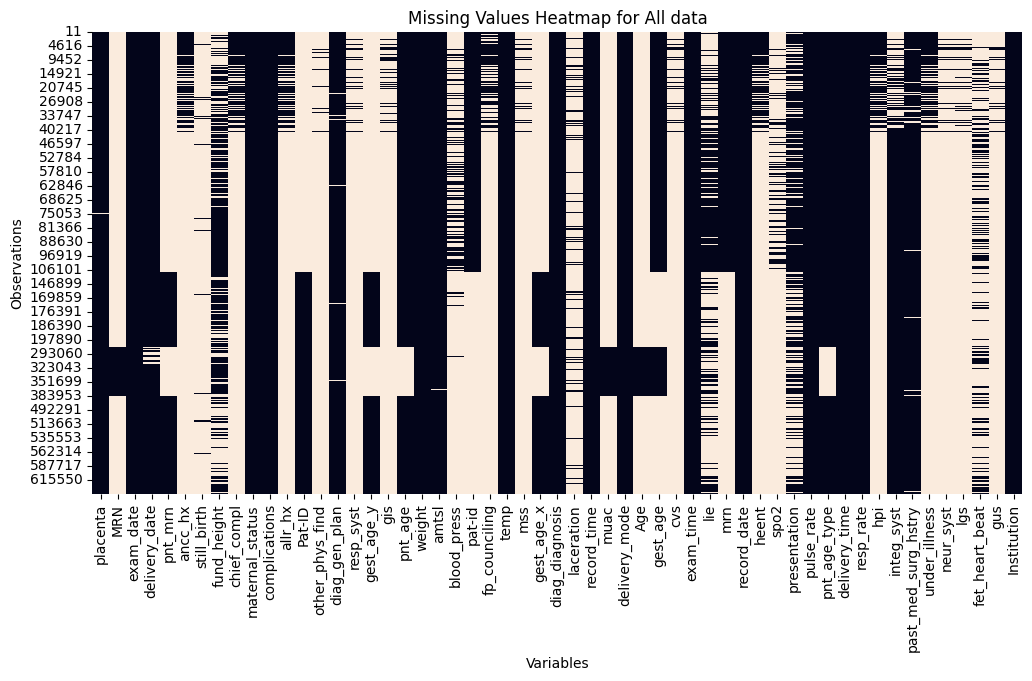

In [8]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap for All data")
plt.xlabel("Variables")
plt.ylabel("Observations")
plt.show()

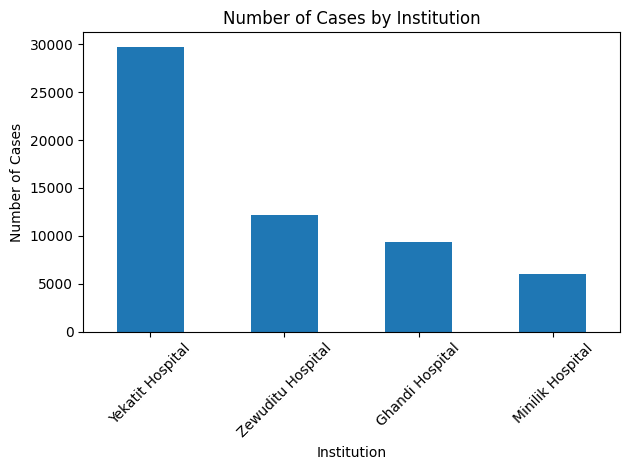

In [9]:
# Count number of cases per institution
counts = df['Institution'].value_counts()

# Plot
counts.plot(kind='bar')

# Labels and title
plt.xlabel('Institution')
plt.ylabel('Number of Cases')
plt.title('Number of Cases by Institution')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 57287 entries, 11 to 645819
Data columns (total 55 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   placenta             57228 non-null  object 
 1   MRN                  6026 non-null   float64
 2   exam_date            57287 non-null  object 
 3   delivery_date        56186 non-null  object 
 4   pnt_mrn              21494 non-null  float64
 5   ancc_hx              9543 non-null   object 
 6   still_birth          1368 non-null   object 
 7   fund_height          37268 non-null  object 
 8   chief_compl          9542 non-null   object 
 9   maternal_status      57287 non-null  object 
 10  complications        57287 non-null  object 
 11  allr_hx              9543 non-null   object 
 12  Pat-ID               27528 non-null  float64
 13  other_phys_find      680 non-null    object 
 14  diag_gen_plan        56836 non-null  object 
 15  resp_syst            1984 non-null   ob

In [11]:
# Confirm changes
print(df['complications'].value_counts())

complications
none,                                                              53358
Others specify,                                                     1947
Pre-eclampsia,                                                       920
APH,                                                                 284
PPH,                                                                 262
OL/Prolonged labor,                                                  124
retroviral infection,                                                112
epilepsy,                                                             91
none,Others specify,                                                  57
Eclampsia,                                                            31
Ruptured Uterus,                                                      15
epilepsy,none,                                                        13
OL/Prolonged labor,none,                                              11
PPH,none,                            

In [12]:
# Confirm changes
print(df['delivery_mode'].value_counts())

delivery_mode
Caesarean section                20214
Normal delivery SVD              16916
SVD                              13209
C/S                               5647
Vacuum extraction                  534
Assisted breech delivery           248
Forceps delivery                   212
Assisted Breech delivery           168
Episiotomy                          52
Abdominal surgical deliveries       34
Others                              18
Craniotomy                          12
Abdominal surgical delivery         10
Other                                9
Other Destructive delivery           4
Name: count, dtype: int64


In [13]:
# Work on a safe copy
df = df.copy()

# Standardize text
df['delivery_mode'] = (
    df['delivery_mode']
    .astype(str)
    .str.strip()
    .str.lower()
)

# Initialize new column
df['delivery_mode_clean'] = 'Other'

# 1. Normal Vaginal Delivery
mask_nvd = df['delivery_mode'].str.contains(
    r'\b(svd|normal delivery|spontaneous vaginal delivery)\b', na=False
)
df.loc[mask_nvd, 'delivery_mode_clean'] = 'Normal Vaginal Delivery'

# 2. Cesarean Section
mask_cs = df['delivery_mode'].str.contains(
    r'\b(c/s|caesarean|cesarean|abdominal surgical)\b', na=False
)
df.loc[mask_cs, 'delivery_mode_clean'] = 'Cesarean Section'

# 3. Assisted Vaginal Delivery
mask_avd = df['delivery_mode'].str.contains(
    r'\b(vacuum|Forceps |assisted breech|Breech)\b', na=False
)
df.loc[mask_avd, 'delivery_mode_clean'] = 'Assisted Vaginal Delivery'

# Check result
df['delivery_mode_clean'].value_counts()

delivery_mode_clean
Normal Vaginal Delivery      30125
Cesarean Section             25905
Assisted Vaginal Delivery      950
Other                          307
Name: count, dtype: int64

In [14]:
# Create a working copy of the DataFrame
df = df.copy()

# 1. Create an indicator column for Cesarean Section cases
df['Cesarean Section'] = df['delivery_mode_clean'].str.contains(
    r'Cesarean Section',  # Broad but targeted matching
    case=False, 
    na=False,
    regex=True
).astype(int)

df["Cesarean Section"].value_counts()

Cesarean Section
0    31382
1    25905
Name: count, dtype: int64

In [15]:
# Work on a safe copy
df = df.copy()

# Standardize text
df['presentation'] = (
    df['presentation']
    .astype(str)
    .str.strip()
    .str.lower()
)

# Initialize new column
df['presentation_clean'] = 'NA'

# 1. Cephalic (Vertex)
mask_cephalic = df['presentation'].str.contains(
    r'\b(ce|cephalic|ve|vertex|oc|occiput|oa|op)\b', na=False
)
df.loc[mask_cephalic, 'presentation_clean'] = 'Cephalic'

# 2. Breech
mask_breech = df['presentation'].str.contains(
    r'\b(br|breech|frank breech|complete breech|footling)\b', na=False
)
df.loc[mask_breech, 'presentation_clean'] = 'Breech'

# 3. Transverse / Shoulder
mask_transverse = df['presentation'].str.contains(
    r'\b(tran|transverse|sho|shoulder|obl|oblique)\b', na=False
)
df.loc[mask_transverse, 'presentation_clean'] = 'Transverse/Shoulder'

# 4. Face / Brow (less common but important)
mask_face = df['presentation'].str.contains(
    r'\b(face|brow)\b', na=False
)
df.loc[mask_face, 'presentation_clean'] = 'Face/Brow'

# Check distribution
df['presentation_clean'].value_counts(dropna=False)

presentation_clean
NA                     36793
Cephalic               18449
Breech                  1957
Transverse/Shoulder       88
Name: count, dtype: int64

In [16]:
# Work on a safe copy
df = df.copy()

# Standardize text
df['lie'] = (
    df['lie']
    .astype(str)
    .str.strip()
    .str.lower()
)

# Initialize new column
df['lie_clean'] = 'NA'

# 1. Longitudinal Lie (normal)
mask_longitudinal = df['lie'].str.contains(
    r'\b(ll|l|longitudinal|longitudinal lie)\b', na=False
)
df.loc[mask_longitudinal, 'lie_clean'] = 'Longitudinal'

# 2. Transverse Lie
mask_transverse = df['lie'].str.contains(
    r'\b(tr|transverse|transverse lie)\b', na=False
)
df.loc[mask_transverse, 'lie_clean'] = 'Transverse'

# 3. Oblique Lie
mask_oblique = df['lie'].str.contains(
    r'\b(ob|oblique|oblique lie)\b', na=False
)
df.loc[mask_oblique, 'lie_clean'] = 'Oblique'

# Check distribution
df['lie_clean'].value_counts(dropna=False)

lie_clean
NA              45403
Longitudinal    11624
Transverse        157
Oblique           103
Name: count, dtype: int64

In [17]:
# Work on a safe copy
df = df.copy()

col = 'past_med_surg_hstry'

# Standardize text
df[col] = (
    df[col]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Replace common "no history" values with NaN
df[col] = df[col].replace(
    ['none', 'no', 'no history', 'nil', 'nill', 'unknown', 'nan'],
    pd.NA
)

# -------- Create clinically meaningful flags -------- #

# 1. Hypertension
df['hx_hypertension'] = df[col].str.contains(
    r'\b(htn|hypertension|pre|preeclampsia|eclampsia)\b', na=False
).astype(int)

# 2. Diabetes
df['hx_diabetes'] = df[col].str.contains(
    r'\b(dm|diabetes|diabetic)\b', na=False
).astype(int)

# 3. Cardiac disease
df['hx_cardiac'] = df[col].str.contains(
    r'\b(cardiac|heart disease|chd)\b', na=False
).astype(int)

# 4. Previous surgery (especially C/S)
df['hx_surgery'] = df[col].str.contains(
    r'\b(surgery|operation|laparotomy|cs|c/s|cesarean|ces)\b', na=False
).astype(int)

# 5. Previous obstetric complications
df['hx_obstetric'] = df[col].str.contains(
    r'\b(pph|hemorrhage|abortion|stillbirth|preterm|obstructed labor|ol)\b', na=False
).astype(int)

# 6. Infectious diseases
df['hx_infection'] = df[col].str.contains(
    r'\b(hiv|tb|tuberculosis|hepatitis|malaria)\b', na=False
).astype(int)

# 7. Anemia
df['hx_anemia'] = df[col].str.contains(
    r'\b(anemia|anaemia)\b', na=False
).astype(int)

# Check summary
df[
    [
        'hx_hypertension', 'hx_diabetes', 'hx_cardiac',
        'hx_surgery', 'hx_obstetric', 'hx_infection',
        'hx_anemia'
    ]
].sum()

hx_hypertension     521
hx_diabetes         530
hx_cardiac           48
hx_surgery         6129
hx_obstetric         19
hx_infection         27
hx_anemia             3
dtype: int64

In [18]:
# Create a working copy of the DataFrame
df = df.copy()

# 1. Create an indicator column for Pre-eclampsia cases
df['Long labour'] = df['complications'].str.contains(
    r'Long labour|prolonged labour|prolonged labor|OL|OL',  # Broad but targeted matching
    case=False, 
    na=False,
    regex=True
).astype(int)

df["Long labour"].value_counts()

Long labour
0    57150
1      137
Name: count, dtype: int64

In [19]:
# Create a working copy of the DataFrame
df = df.copy()

# 1. Create an indicator column for Pre-eclampsia cases
df['APH'] = df['complications'].str.contains(
    r'APH',  # Broad but targeted matching
    case=False, 
    na=False,
    regex=True
).astype(int)

df["APH"].value_counts()

APH
0    56981
1      306
Name: count, dtype: int64

In [20]:
# Split into systolic and diastolic components
df[['bp_systolic', 'bp_diastolic']] = (
    df['blood_press']
    .str.extract(r'(\d+)\s*\/\s*(\d+)')  # Matches "120/80" or "120 / 80"
    .astype(float)  # Convert extracted strings to float
)

In [21]:
# Create a working copy of the DataFrame
df = df.copy()

# 1. Create an indicator column for Pre-eclampsia cases (without label encoding)
df['Pre_eclampsia'] = df['complications'].str.contains(
    r'-?pre-eclampsia|pre-?eclampsia|PE|eclampsi|PRE-ECLAMP|Oedema, proteinuria|PRE ECLMPSIA',  # Broad but targeted matching
    case=False, 
    na=False,
    regex=True
).astype(int)

# Display the count of Pre-eclampsia cases
print("Pre-eclampsia cases distribution:")
print(df["Pre_eclampsia"].value_counts())

Pre-eclampsia cases distribution:
Pre_eclampsia
0    54296
1     2991
Name: count, dtype: int64


In [22]:
# Create a working copy of the DataFrame
df = df.copy()

# 1. Create an indicator column for Pre-eclampsia cases
df['eclampsia'] = df['complications'].str.contains(
    r'eclampsia',  # Broad but targeted matching
    case=False, 
    na=False,
    regex=True
).astype(int)

df["eclampsia"].value_counts()

eclampsia
0    56307
1      980
Name: count, dtype: int64

In [23]:
import re
import pandas as pd

def extract_info(text):
    data = {
        'gravida': None,
        'para': None
    }

    if not isinstance(text, str):
        return data

    text = text.lower()

    # Extract gravida and para
    g_p_match = re.search(r'g(\d+)[^\w]*p(\d+)', text)
    if g_p_match:
        data['gravida'] = int(g_p_match.group(1))
        data['para'] = int(g_p_match.group(2))

    return data

# Apply the extraction function to text column (replace 'text_column' with your actual column name)
extracted_data = df['hpi'].apply(extract_info)

# Convert the list of dictionaries to a DataFrame
extracted_df = pd.DataFrame(extracted_data.tolist())

# Add the extracted columns to the original DataFrame
df = pd.concat([df, extracted_df], axis=1)
df.head()

,placenta,MRN,exam_date,delivery_date,pnt_mrn,ancc_hx,still_birth,fund_height,chief_compl,maternal_status,...,hx_infection,hx_anemia,Long labour,APH,bp_systolic,bp_diastolic,Pre_eclampsia,eclampsia,gravida,para
11,Completed,NaN,2021-03-01 00:00:00,2021-04-02 00:00:00,NaN,unknown,NaN,40 wk si,come for ANC followup with previous cs SCAR,Stable,...,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN
12,Completed,NaN,2021-03-05 00:00:00,2021-04-02 00:00:00,NaN,unknown,NaN,NaN,referred from hc for a case of for 1 previous...,Stable,...,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,2.0,1.0
20,Completed,NaN,2021-03-01 00:00:00,2021-03-08 00:00:00,NaN,no,"[""Fresh""]",NaN,referred from Hc as a case of oligohydraminos,Stable,...,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN
23,Completed,NaN,2021-03-01 00:00:00,2021-09-10 00:00:00,NaN,no,NaN,-,Regular ANC follow up,Stable,...,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN
25,Completed,NaN,2021-03-01 00:00:00,2021-05-08 00:00:00,NaN,no,NaN,NaN,referred from hc for a case of mild polyhydram...,Stable,...,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 97384 entries, 11 to 57281
Data columns (total 74 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   placenta             57228 non-null  object 
 1   MRN                  6026 non-null   float64
 2   exam_date            57287 non-null  object 
 3   delivery_date        56186 non-null  object 
 4   pnt_mrn              21494 non-null  float64
 5   ancc_hx              9543 non-null   object 
 6   still_birth          1368 non-null   object 
 7   fund_height          37268 non-null  object 
 8   chief_compl          9542 non-null   object 
 9   maternal_status      57287 non-null  object 
 10  complications        57287 non-null  object 
 11  allr_hx              9543 non-null   object 
 12  Pat-ID               27528 non-null  float64
 13  other_phys_find      680 non-null    object 
 14  diag_gen_plan        56836 non-null  object 
 15  resp_syst            1984 non-null   obj

In [25]:
# Clean feature list
features = [
    'MRN', 'delivery_date', 'fund_height',
    'pnt_age', 'weight',
    'gest_age', 'presentation_clean', 'lie_clean', 'placenta',
    'maternal_status', 'hx_hypertension', 'hx_diabetes', 'hx_cardiac',
    'hx_surgery', 'hx_obstetric', 'hx_infection', 'hx_anemia',
    'pulse_rate', 'resp_rate', 'temp', 'spo2',
    'fet_heart_beat', 'APH', 'bp_systolic', 'bp_diastolic',
    'Pre_eclampsia', 'eclampsia',
    'gravida', 'para', 'Long_labour',
    'Institution', 
]

# Optional: standardize column names (recommended)
df.columns = df.columns.str.strip()

# Keep only available columns (prevents crash)
available_features = [col for col in features if col in df.columns]

# Subset dataframe
df = df[available_features + ['Cesarean Section']]

In [26]:
df

,MRN,delivery_date,fund_height,pnt_age,weight,gest_age,presentation_clean,lie_clean,placenta,maternal_status,...,fet_heart_beat,APH,bp_systolic,bp_diastolic,Pre_eclampsia,eclampsia,gravida,para,Institution,Cesarean Section
11,NaN,2021-04-02 00:00:00,40 wk si,32.0,0.0,Term,NA,NA,Completed,Stable,...,NaN,0.0,NaN,NaN,0.0,0.0,NaN,NaN,Yekatit Hospital,1.0
12,NaN,2021-04-02 00:00:00,NaN,32.0,0.0,Term,NA,NA,Completed,Stable,...,POSITIVE,0.0,NaN,NaN,0.0,0.0,2.0,1.0,Yekatit Hospital,1.0
20,NaN,2021-03-08 00:00:00,NaN,28.0,0.0,Pre-term,NA,NA,Completed,Stable,...,72bpm,0.0,NaN,NaN,0.0,0.0,NaN,NaN,Yekatit Hospital,1.0
23,NaN,2021-09-10 00:00:00,-,33.0,0.0,Term,NA,NA,Completed,Stable,...,NaN,0.0,NaN,NaN,0.0,0.0,NaN,NaN,Yekatit Hospital,0.0
25,NaN,2021-05-08 00:00:00,NaN,26.0,0.0,Post-term,Breech,NA,Completed,Stable,...,NaN,0.0,NaN,NaN,0.0,0.0,NaN,NaN,Yekatit Hospital,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57268,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57270,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57271,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57280,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
threshold_row = 0.4 * df.shape[1]   # at least 70% non-missing required
df = df.dropna(axis=0, thresh=threshold_row)

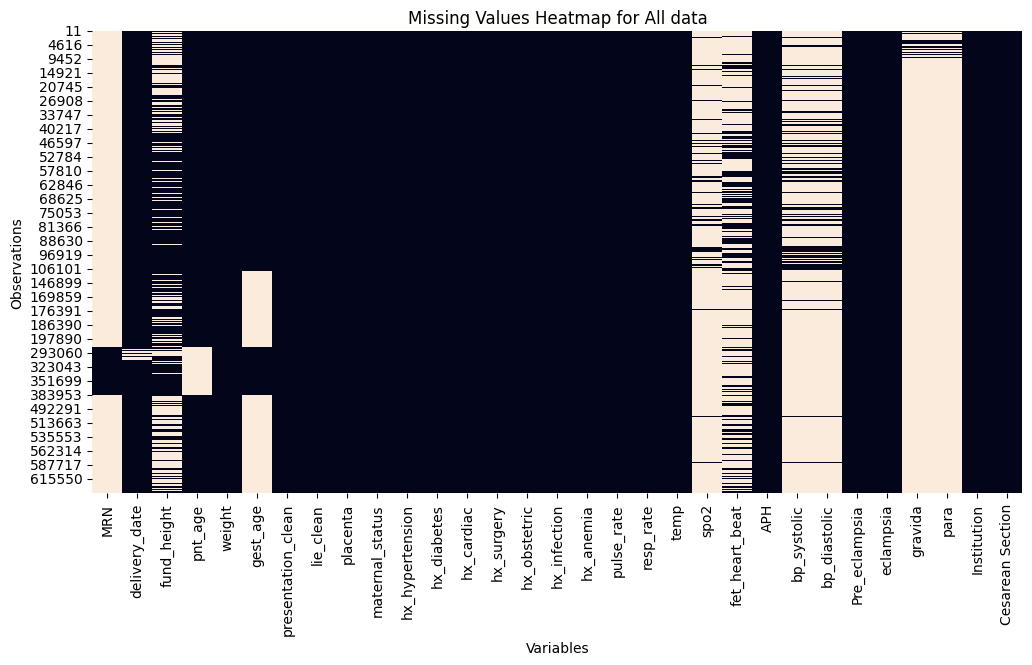

In [28]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap for All data")
plt.xlabel("Variables")
plt.ylabel("Observations")
plt.show()

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 57287 entries, 11 to 645819
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   MRN                 6026 non-null   float64
 1   delivery_date       56186 non-null  object 
 2   fund_height         37268 non-null  object 
 3   pnt_age             51253 non-null  float64
 4   weight              57287 non-null  float64
 5   gest_age            35785 non-null  object 
 6   presentation_clean  57287 non-null  object 
 7   lie_clean           57287 non-null  object 
 8   placenta            57228 non-null  object 
 9   maternal_status     57287 non-null  object 
 10  hx_hypertension     57287 non-null  float64
 11  hx_diabetes         57287 non-null  float64
 12  hx_cardiac          57287 non-null  float64
 13  hx_surgery          57287 non-null  float64
 14  hx_obstetric        57287 non-null  float64
 15  hx_infection        57287 non-null  float64
 16  hx_anem

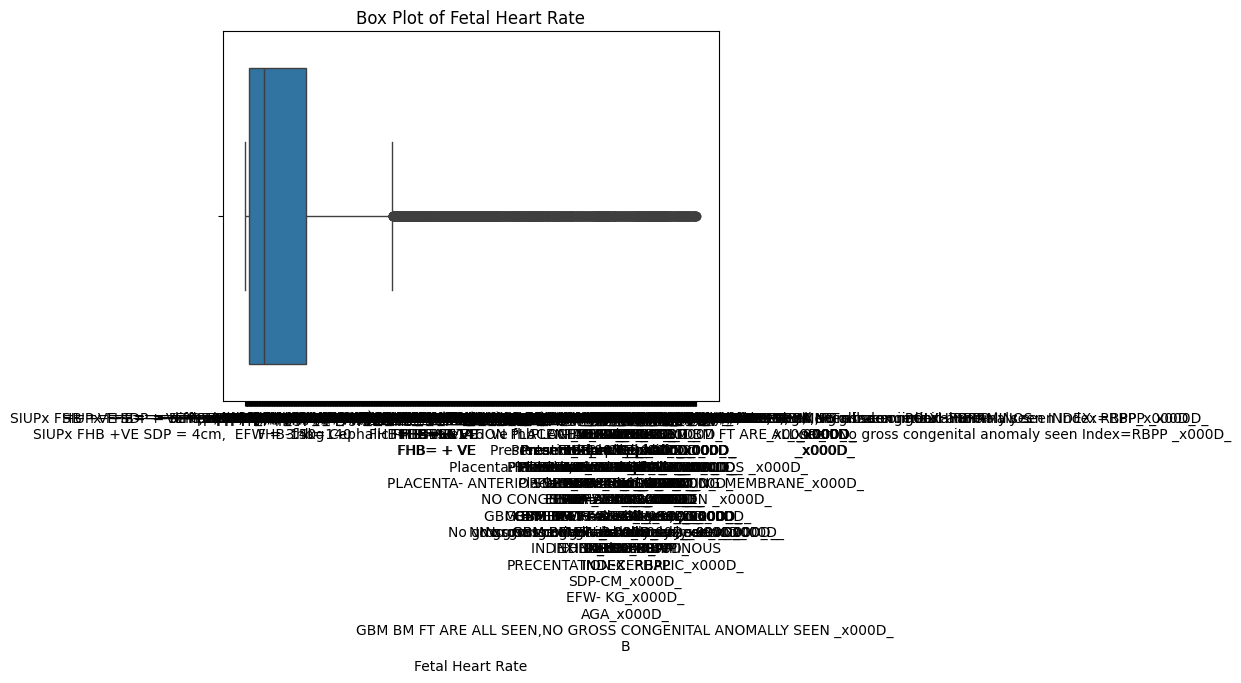

In [30]:
# Step 2: Plot the cleaned column
sns.boxplot(x=df['fet_heart_beat'])
plt.title('Box Plot of Fetal Heart Rate')
plt.xlabel('Fetal Heart Rate')
plt.show()

In [31]:
df["fund_height"].value_counts()

fund_height
-                                      2735
TERM                                   1851
TERM SIZED                             1480
TERM SIZE                               939
36                                      916
                                       ... 
36 wk sized gravid ux                     1
24 WEEKS SIZE GRAVVID UX                  1
TERM SIZED GRAVID UTRES 2C/10/20-30       1
  18WEEKS                                 1
28WKA                                     1
Name: count, Length: 3866, dtype: int64

In [32]:
df['fund_height'] = (
    df['fund_height']
    .astype(str)
    .str.findall(r'\d+')
    .str[0]                      # take first number
    .astype(float)
    .astype('Int64')
)

In [33]:
df['fet_heart_beat'] = (
    df['fet_heart_beat']
    .astype(str)
    .str.findall(r'\d+')
    .str[0]                      # take first number
    .astype(float)
    .astype('Int64')
)

# Treating Outliers

In [34]:
def remove_outliers_iqr(df, columns):
    df = df.copy()
    mask = pd.Series(True, index=df.index)

    for col in columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.95)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        mask &= df[col].between(lower, upper) | df[col].isna()

    return df[mask]

In [35]:
df

,MRN,delivery_date,fund_height,pnt_age,weight,gest_age,presentation_clean,lie_clean,placenta,maternal_status,...,fet_heart_beat,APH,bp_systolic,bp_diastolic,Pre_eclampsia,eclampsia,gravida,para,Institution,Cesarean Section
11,NaN,2021-04-02 00:00:00,40,32.0,0.0,Term,NA,NA,Completed,Stable,...,<NA>,0.0,NaN,NaN,0.0,0.0,NaN,NaN,Yekatit Hospital,1.0
12,NaN,2021-04-02 00:00:00,<NA>,32.0,0.0,Term,NA,NA,Completed,Stable,...,<NA>,0.0,NaN,NaN,0.0,0.0,2.0,1.0,Yekatit Hospital,1.0
20,NaN,2021-03-08 00:00:00,<NA>,28.0,0.0,Pre-term,NA,NA,Completed,Stable,...,72,0.0,NaN,NaN,0.0,0.0,NaN,NaN,Yekatit Hospital,1.0
23,NaN,2021-09-10 00:00:00,<NA>,33.0,0.0,Term,NA,NA,Completed,Stable,...,<NA>,0.0,NaN,NaN,0.0,0.0,NaN,NaN,Yekatit Hospital,0.0
25,NaN,2021-05-08 00:00:00,<NA>,26.0,0.0,Post-term,Breech,NA,Completed,Stable,...,<NA>,0.0,NaN,NaN,0.0,0.0,NaN,NaN,Yekatit Hospital,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
645360,NaN,2026-03-14 00:00:00,<NA>,25.0,0.0,NaN,NA,NA,Completed,Stable,...,<NA>,0.0,NaN,NaN,0.0,0.0,NaN,NaN,Zewuditu Hospital,1.0
645436,NaN,2026-03-15 00:00:00,34,26.0,0.0,NaN,Breech,NA,Completed,Stable,...,<NA>,0.0,NaN,NaN,0.0,0.0,NaN,NaN,Zewuditu Hospital,0.0
645667,NaN,2026-03-17 00:00:00,<NA>,26.0,0.0,NaN,NA,NA,Completed,Stable,...,<NA>,0.0,NaN,NaN,0.0,0.0,NaN,NaN,Zewuditu Hospital,0.0
645713,NaN,2026-03-17 00:00:00,<NA>,22.0,0.0,NaN,NA,NA,Completed,Stable,...,<NA>,0.0,NaN,NaN,0.0,0.0,NaN,NaN,Zewuditu Hospital,0.0


In [36]:
df = remove_outliers_iqr(df, [
    'fund_height', 'pnt_age', 'pulse_rate', 'resp_rate', 'temp',
    'spo2', 'fet_heart_beat', 'bp_systolic', 'bp_diastolic', 'para'
])

In [37]:

df['weight'] = df['weight'].replace(0, np.nan)

df['pulse_rate'] = df['pulse_rate'].replace(0, np.nan)

df['resp_rate'] = df['resp_rate'].replace(0, np.nan)

df['temp'] = df['temp'].replace(0, np.nan)

df['bp_systolic'] = df['bp_systolic'].replace(0, np.nan)

df['weight'] = df['weight'].replace(0, np.nan)

df['presentation_clean'] = df['presentation_clean'].replace('NA', np.nan)

df['lie_clean'] = df['lie_clean'].replace('NA', np.nan)


In [38]:
df

,MRN,delivery_date,fund_height,pnt_age,weight,gest_age,presentation_clean,lie_clean,placenta,maternal_status,...,fet_heart_beat,APH,bp_systolic,bp_diastolic,Pre_eclampsia,eclampsia,gravida,para,Institution,Cesarean Section
11,NaN,2021-04-02 00:00:00,40,32.0,NaN,Term,NaN,NaN,Completed,Stable,...,<NA>,0.0,NaN,NaN,0.0,0.0,NaN,NaN,Yekatit Hospital,1.0
12,NaN,2021-04-02 00:00:00,<NA>,32.0,NaN,Term,NaN,NaN,Completed,Stable,...,<NA>,0.0,NaN,NaN,0.0,0.0,2.0,1.0,Yekatit Hospital,1.0
23,NaN,2021-09-10 00:00:00,<NA>,33.0,NaN,Term,NaN,NaN,Completed,Stable,...,<NA>,0.0,NaN,NaN,0.0,0.0,NaN,NaN,Yekatit Hospital,0.0
25,NaN,2021-05-08 00:00:00,<NA>,26.0,NaN,Post-term,Breech,NaN,Completed,Stable,...,<NA>,0.0,NaN,NaN,0.0,0.0,NaN,NaN,Yekatit Hospital,1.0
26,NaN,2021-05-08 00:00:00,38,26.0,NaN,Post-term,NaN,NaN,Completed,Stable,...,<NA>,0.0,NaN,NaN,0.0,0.0,NaN,NaN,Yekatit Hospital,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
645360,NaN,2026-03-14 00:00:00,<NA>,25.0,NaN,NaN,NaN,NaN,Completed,Stable,...,<NA>,0.0,NaN,NaN,0.0,0.0,NaN,NaN,Zewuditu Hospital,1.0
645436,NaN,2026-03-15 00:00:00,34,26.0,NaN,NaN,Breech,NaN,Completed,Stable,...,<NA>,0.0,NaN,NaN,0.0,0.0,NaN,NaN,Zewuditu Hospital,0.0
645667,NaN,2026-03-17 00:00:00,<NA>,26.0,NaN,NaN,NaN,NaN,Completed,Stable,...,<NA>,0.0,NaN,NaN,0.0,0.0,NaN,NaN,Zewuditu Hospital,0.0
645713,NaN,2026-03-17 00:00:00,<NA>,22.0,NaN,NaN,NaN,NaN,Completed,Stable,...,<NA>,0.0,NaN,NaN,0.0,0.0,NaN,NaN,Zewuditu Hospital,0.0


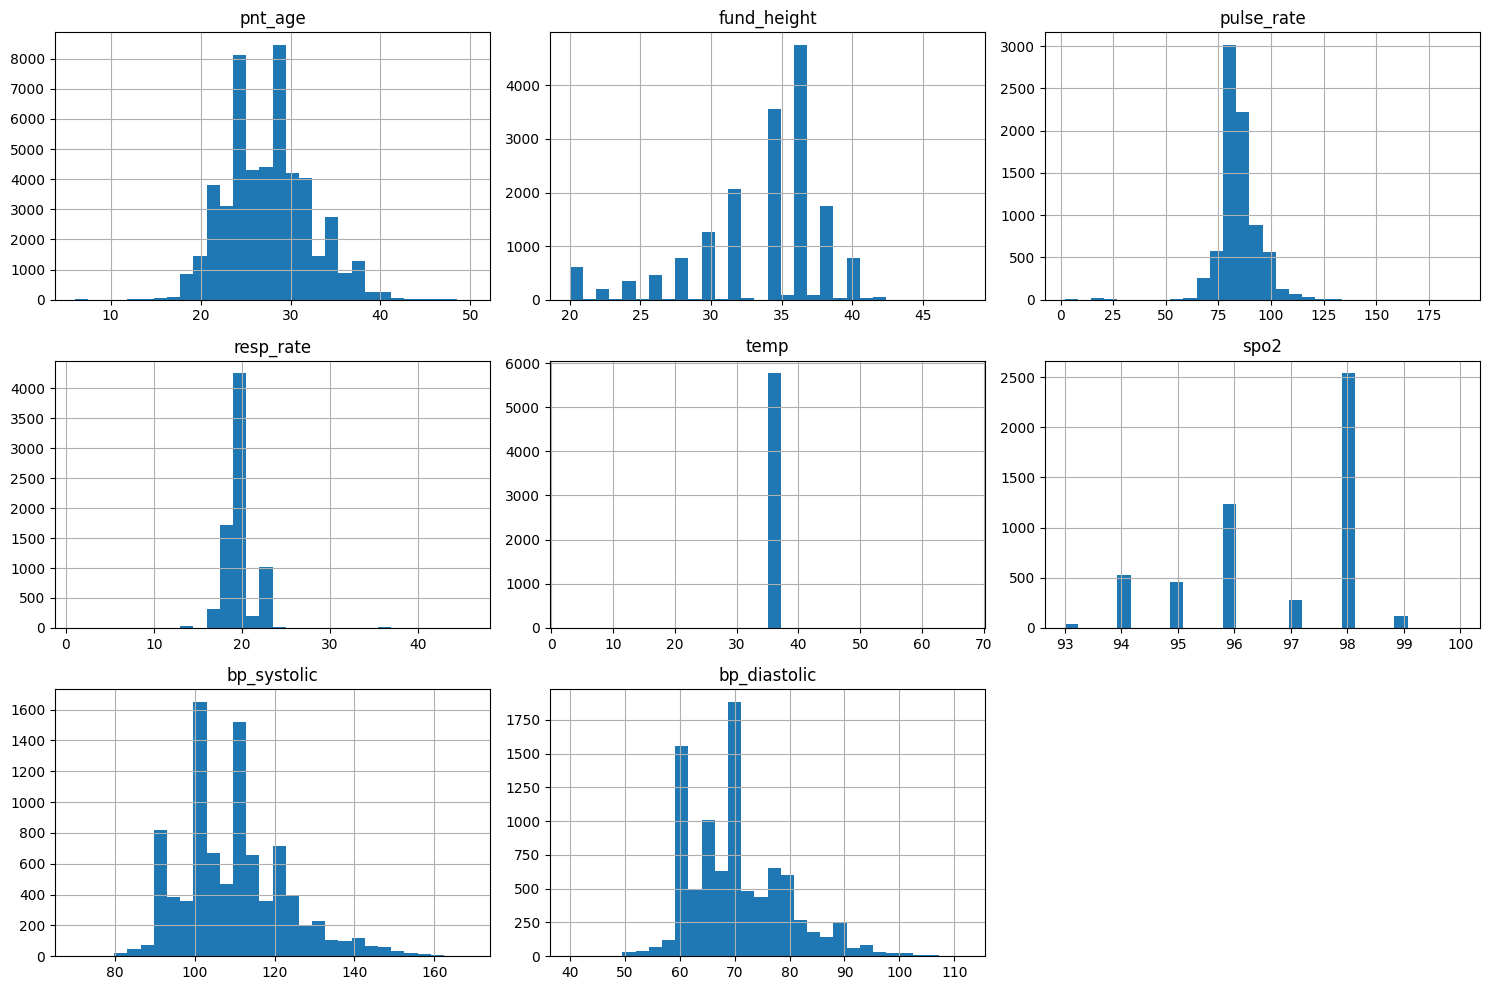

In [39]:
num_cols = [
    'pnt_age', 'fund_height', 'pulse_rate', 'resp_rate',
    'temp', 'spo2', 'bp_systolic', 'bp_diastolic'
]

df[num_cols].hist(bins=30, figsize=(15,10))
plt.tight_layout()
plt.show()

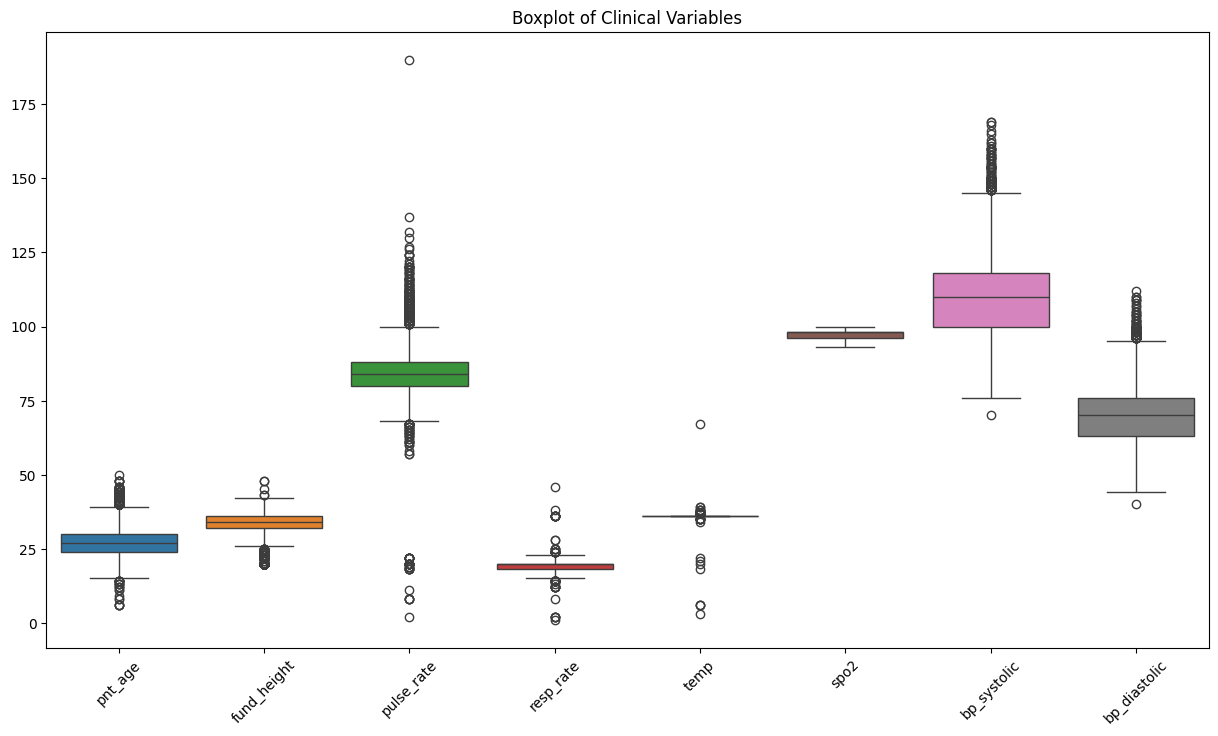

In [40]:
plt.figure(figsize=(15,8))
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=45)
plt.title("Boxplot of Clinical Variables")
plt.show()

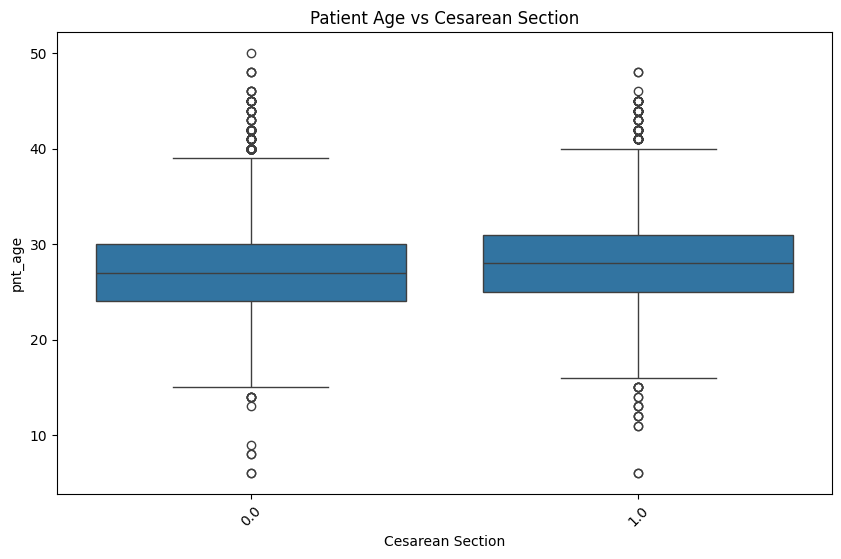

In [41]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Cesarean Section', y='pnt_age', data=df)
plt.xticks(rotation=45)
plt.title("Patient Age vs Cesarean Section")
plt.show()

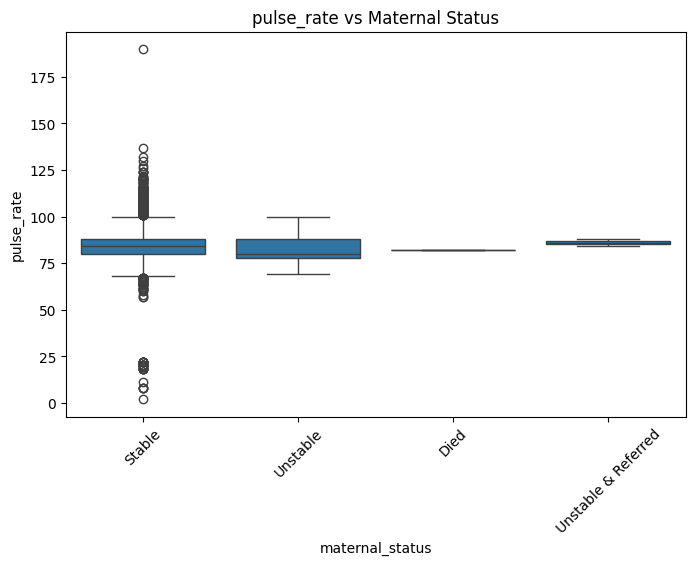

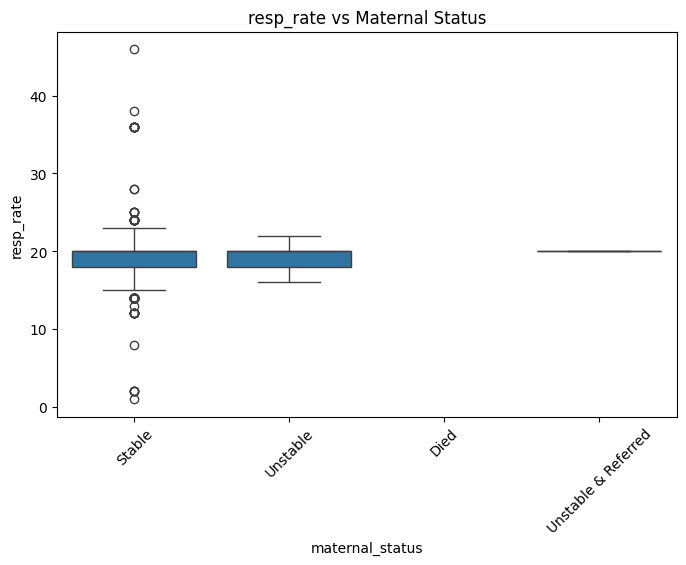

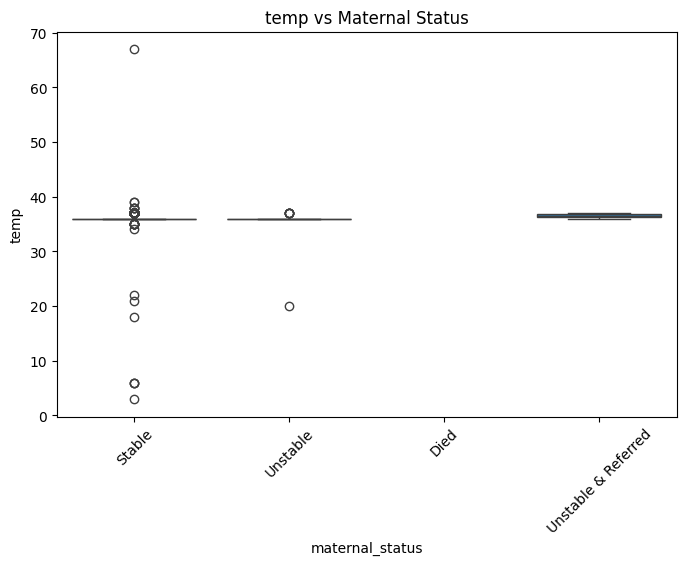

In [42]:
vitals = ['pulse_rate', 'resp_rate', 'temp']

for col in vitals:
    plt.figure(figsize=(8,5))
    sns.boxplot(x='maternal_status', y=col, data=df)
    plt.title(f"{col} vs Maternal Status")
    plt.xticks(rotation=45)
    plt.show()

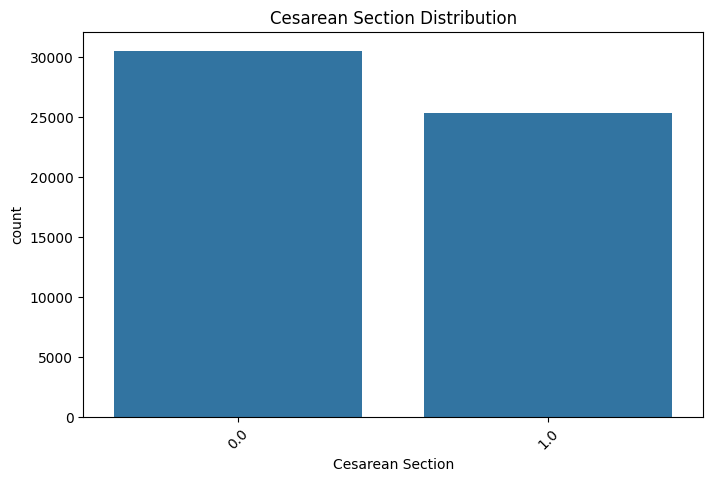

In [43]:
plt.figure(figsize=(8,5))
sns.countplot(x='Cesarean Section', data=df)
plt.xticks(rotation=45)
plt.title("Cesarean Section Distribution")
plt.show()

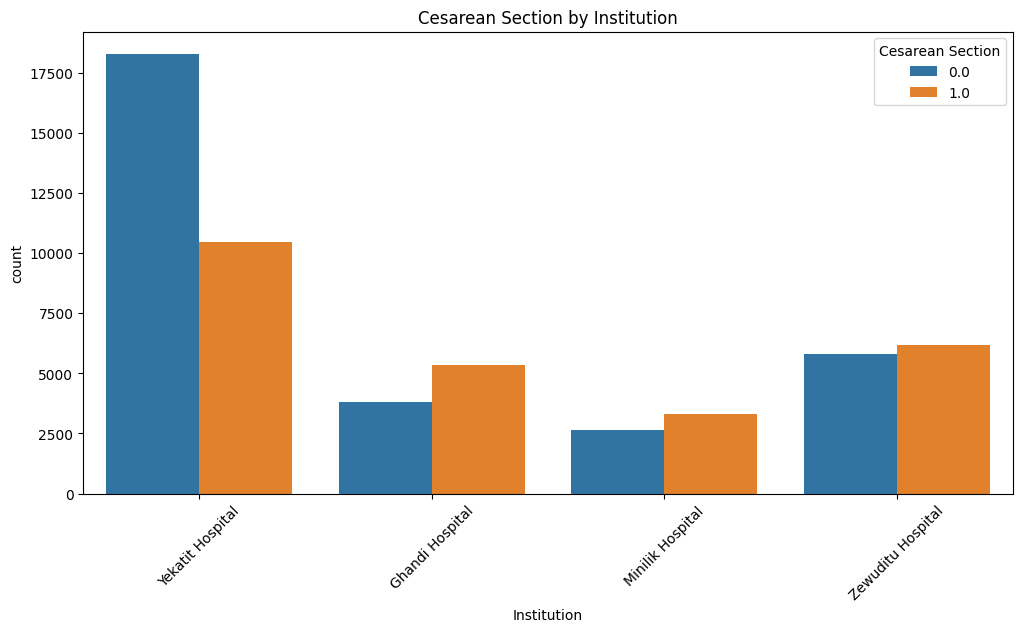

In [44]:
plt.figure(figsize=(12,6))
sns.countplot(x='Institution', hue='Cesarean Section', data=df)
plt.xticks(rotation=45)
plt.title("Cesarean Section by Institution")
plt.show()

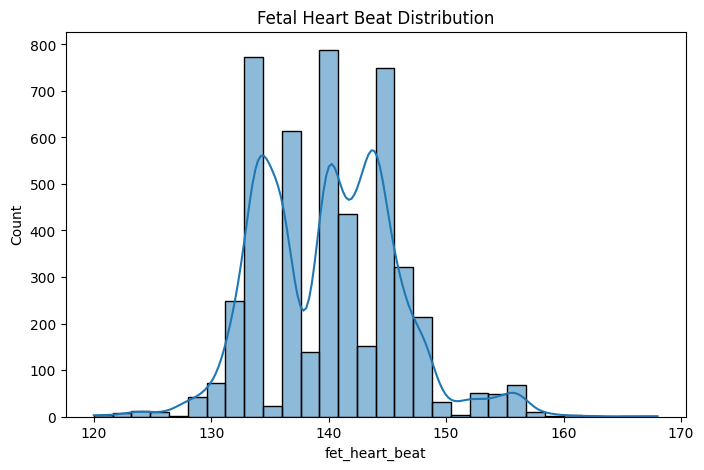

In [45]:
plt.figure(figsize=(8,5))
sns.histplot(df['fet_heart_beat'].dropna(), bins=30, kde=True)
plt.title("Fetal Heart Beat Distribution")
plt.show()

In [46]:
df = df.rename(columns={
    'MRN': 'patient_id',
    'delivery_date': 'delivery_datetime',
    'fund_height': 'fundal_height_cm',
    'pnt_age': 'maternal_age_years',
    'weight': 'maternal_weight_kg',
    'muac': 'muac_cm',
    'gest_age': 'gestational_age_weeks',
    'presentation_clean': 'fetal_presentation',
    'lie_clean': 'fetal_lie',
    'placenta': 'placenta_status',
    'maternal_status': 'maternal_outcome_status',

    'hx_hypertension': 'history_hypertension',
    'hx_diabetes': 'history_diabetes',
    'hx_cardiac': 'history_cardiac_disease',
    'hx_surgery': 'history_surgery',
    'hx_obstetric': 'history_obstetric_complications',
    'hx_infection': 'history_infection',
    'hx_anemia': 'history_anemia',

    'pulse_rate': 'maternal_pulse_rate_bpm',
    'resp_rate': 'maternal_respiratory_rate_bpm',
    'temp': 'maternal_temperature_c',
    'spo2': 'maternal_oxygen_saturation_percent',
    'fet_heart_beat': 'fetal_heart_rate_bpm',

    'APH': 'antepartum_hemorrhage',
    'bp_systolic': 'systolic_blood_pressure_mmhg',
    'bp_diastolic': 'diastolic_blood_pressure_mmhg',

    'Pre_eclampsia': 'preeclampsia',
    'eclampsia': 'eclampsia',

    'gravida': 'gravidity',
    'para': 'parity',

    'Institution': 'health_facility',
    'Cesarean Section': 'Cesarean Section'
})

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 55883 entries, 11 to 645819
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   patient_id                          5963 non-null   float64
 1   delivery_datetime                   54788 non-null  object 
 2   fundal_height_cm                    16918 non-null  Int64  
 3   maternal_age_years                  49913 non-null  float64
 4   maternal_weight_kg                  1300 non-null   float64
 5   gestational_age_weeks               34727 non-null  object 
 6   fetal_presentation                  20149 non-null  object 
 7   fetal_lie                           11602 non-null  object 
 8   placenta_status                     55825 non-null  object 
 9   maternal_outcome_status             55883 non-null  object 
 10  history_hypertension                55883 non-null  float64
 11  history_diabetes                    55883 no

# Missing value Inputation

In [48]:
import numpy as np
import pandas as pd

def probabilistic_imputation(df, random_state=42):
    np.random.seed(random_state)
    df = df.copy()

    for col in df.columns:
        # Skip columns with all missing values
        if df[col].isna().all():
            continue
        
        # Get non-missing values
        observed = df[col].dropna()
        
        # Indices where values are missing
        missing_idx = df[df[col].isna()].index
        
        if len(missing_idx) > 0:
            # Sample with replacement from observed values
            imputed_values = np.random.choice(observed, size=len(missing_idx), replace=True)
            
            # Fill missing values
            df.loc[missing_idx, col] = imputed_values

    return df

In [49]:
df = probabilistic_imputation(df)

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 55883 entries, 11 to 645819
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   patient_id                          55883 non-null  float64
 1   delivery_datetime                   55883 non-null  object 
 2   fundal_height_cm                    55883 non-null  Int64  
 3   maternal_age_years                  55883 non-null  float64
 4   maternal_weight_kg                  55883 non-null  float64
 5   gestational_age_weeks               55883 non-null  object 
 6   fetal_presentation                  55883 non-null  object 
 7   fetal_lie                           55883 non-null  object 
 8   placenta_status                     55883 non-null  object 
 9   maternal_outcome_status             55883 non-null  object 
 10  history_hypertension                55883 non-null  float64
 11  history_diabetes                    55883 no

# Date Standardization

In [51]:
df['delivery_datetime'] = pd.to_datetime(
    df['delivery_datetime'],
    errors='coerce',
    dayfirst=False
)

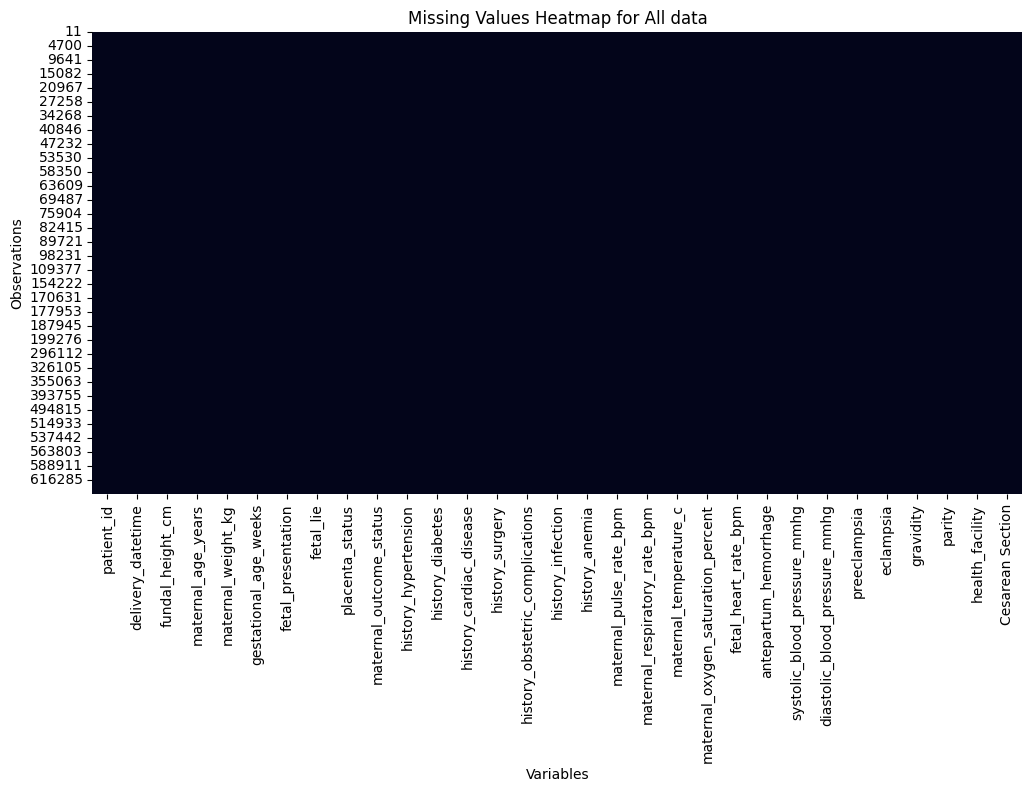

In [52]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap for All data")
plt.xlabel("Variables")
plt.ylabel("Observations")
plt.show()

In [53]:
df.isna().sum()

patient_id                             0
delivery_datetime                     26
fundal_height_cm                       0
maternal_age_years                     0
maternal_weight_kg                     0
gestational_age_weeks                  0
fetal_presentation                     0
fetal_lie                              0
placenta_status                        0
maternal_outcome_status                0
history_hypertension                   0
history_diabetes                       0
history_cardiac_disease                0
history_surgery                        0
history_obstetric_complications        0
history_infection                      0
history_anemia                         0
maternal_pulse_rate_bpm                0
maternal_respiratory_rate_bpm          0
maternal_temperature_c                 0
maternal_oxygen_saturation_percent     0
fetal_heart_rate_bpm                   0
antepartum_hemorrhage                  0
systolic_blood_pressure_mmhg           0
diastolic_blood_

<Figure size 1400x700 with 0 Axes>

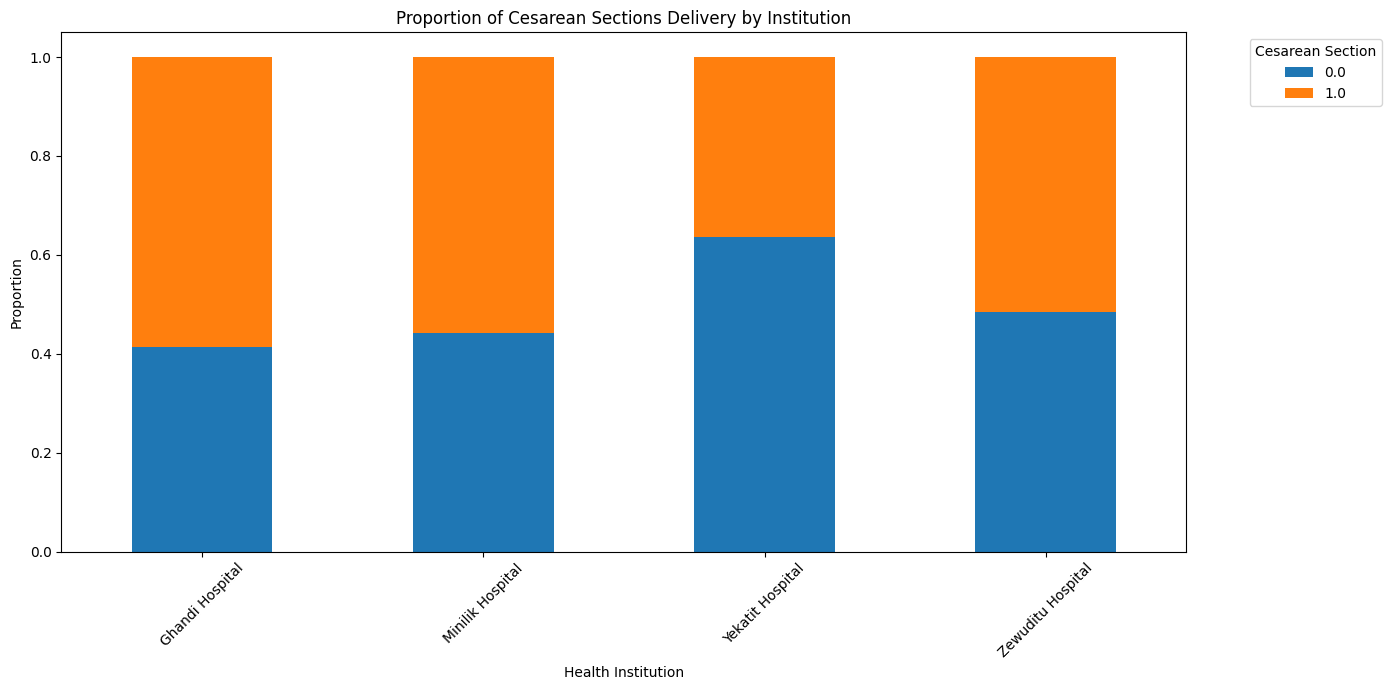

In [54]:
plt.figure(figsize=(14,7))

institution_mode = pd.crosstab(
    df['health_facility'],
    df['Cesarean Section'],
    normalize='index'
)

institution_mode.plot(
    kind='bar',
    stacked=True,
    figsize=(14,7)
)

plt.title("Proportion of Cesarean Sections Delivery by Institution")
plt.xlabel("Health Institution")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.legend(title="Cesarean Section", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

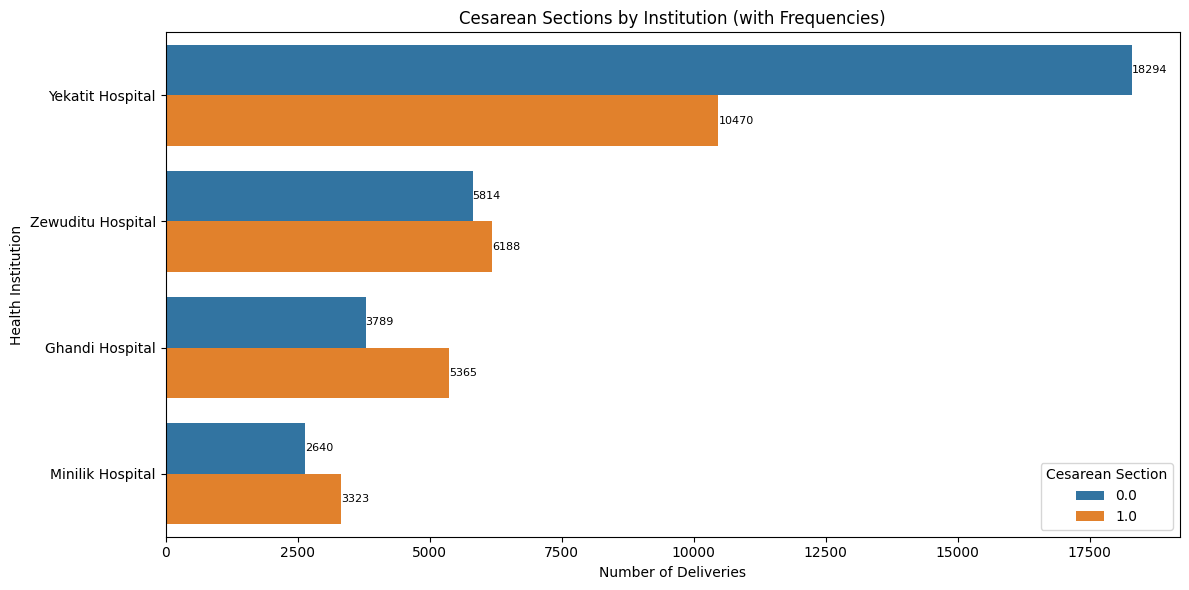

In [55]:
plt.figure(figsize=(12,6))

order = df['health_facility'].value_counts().index

ax = sns.countplot(
    y='health_facility',
    hue='Cesarean Section',
    data=df,
    order=order
)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=8)

plt.title("Cesarean Sections by Institution (with Frequencies)")
plt.xlabel("Number of Deliveries")
plt.ylabel("Health Institution")
plt.legend(title="Cesarean Section")
plt.tight_layout()
plt.show()

In [56]:
df.to_csv("D:/DLM Research/processed_data.csv", index=False)